# Predictive Analysis of Online Shopping Cart Abandonment

**Dataset:** Google BigQuery GA4 Obfuscated Ecommerce Sample — January 2021  
**Methodology:** CRISP-DM  
**Goal:** Predict whether a user session results in a purchase (1) or abandonment (0)

## Data Loading & Initial Inspection

Raw dataset is event-level — each row represents one user interaction.  
- 300,000 rows · 15 columns · 16 unique event types  
- High missing: `session_engaged` (90.8%), `source`/`medium`/`campaign` (~72%), `page_referrer` (73.6%)  
- Columns dropped: `session_engaged` (zero variance), `source`, `medium`, `campaign`, `page_referrer` (>72% missing — imputation not valid for categorical traffic data)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Mining/bq-results-20260225-184505-1772045122868.csv')

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.head(3).to_string())
print(df.isnull().sum())

(300000, 15)
event_date                int64
event_timestamp           int64
event_name               object
user_pseudo_id          float64
device_type              object
country                  object
ga_session_id             int64
ga_session_number         int64
page_location            object
page_referrer            object
source                   object
medium                   object
campaign                 object
engagement_time_msec    float64
session_engaged         float64
dtype: object
   event_date   event_timestamp       event_name  user_pseudo_id device_type        country  ga_session_id  ga_session_number                                                                  page_location page_referrer source medium campaign  engagement_time_msec  session_engaged
0    20210102  1609568188059459        page_view    1.005484e+06     desktop  United States     2718913892                  1  https://shop.googlemerchandisestore.com/Google+Redesign/Shop+by+Brand/YouTube        

## EDA — Raw Engagement Time Distribution

Before any aggregation or cleaning, we examine the raw distribution of `engagement_time_msec`
at event level to understand the data's shape and justify our outlier handling approach.

The histogram reveals extreme right skew (skewness = 394.58) — the vast majority of events
have very low engagement time, while a small number have extremely high values. The isolated
bar at 50,000ms is an artefact of clipping applied for visualisation purposes only.

This confirms that **IQR is the correct outlier method** over z-score. Z-score assumes
normality — with skewness of 394.58, z-score would fail to correctly identify outliers.
IQR is distribution-free and robust to this level of skew.

In [ ]:
print(df['event_name'].value_counts())

event_name
page_view              105400
user_engagement         61685
scroll                  33814
session_start           29481
first_visit             22830
view_item               21130
view_promotion          12102
add_to_cart              3821
begin_checkout           2613
select_item              2577
view_search_results      2008
add_shipping_info         906
select_promotion          699
add_payment_info          608
purchase                  272
click                      54
Name: count, dtype: int64


In [ ]:
print(df.describe(include='all'))

          event_date  event_timestamp event_name  user_pseudo_id device_type  \
count   3.000000e+05     3.000000e+05     300000    3.000000e+05      300000   
unique           NaN              NaN         16             NaN           3   
top              NaN              NaN  page_view             NaN     desktop   
freq             NaN              NaN     105400             NaN      177275   
mean    2.021012e+07     1.610888e+15        NaN    2.421267e+08         NaN   
std     8.924792e+00     7.712571e+11        NaN    1.105739e+09         NaN   
min     2.021010e+07     1.609459e+15        NaN    1.000824e+06         NaN   
25%     2.021011e+07     1.610125e+15        NaN    6.083562e+06         NaN   
50%     2.021012e+07     1.611025e+15        NaN    2.452843e+07         NaN   
75%     2.021012e+07     1.611528e+15        NaN    6.401692e+07         NaN   
max     2.021013e+07     1.612051e+15        NaN    9.984229e+09         NaN   

              country  ga_session_id  g

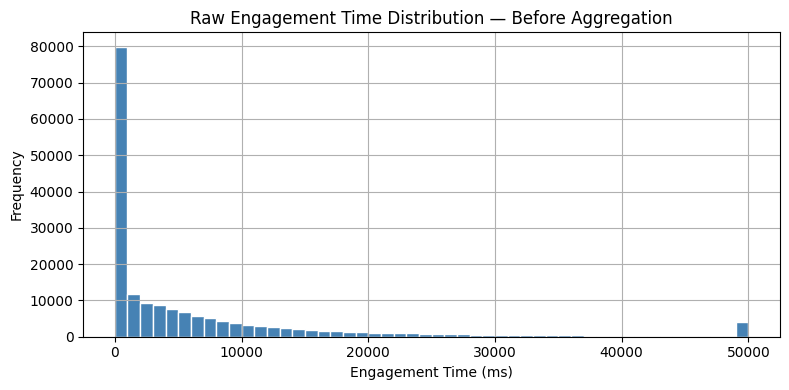

Skewness: 394.58


In [48]:
# EDA — Distribution of engagement time before aggregation
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['engagement_time_msec'].dropna().clip(upper=50000).hist(
    bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Engagement Time (ms)')
plt.ylabel('Frequency')
plt.title('Raw Engagement Time Distribution — Before Aggregation')
plt.tight_layout()
plt.savefig('eda_engagement_distribution.png', dpi=150)
plt.show()
print("Skewness:", df['engagement_time_msec'].skew().round(3))

**Finding:** Skewness of 394.58 at raw event level confirms heavily right-skewed behavioural
data. This justifies IQR-based outlier capping applied in Step 7, and explains why median
is a more representative central tendency measure than mean for this dataset.

## Y Variable Definition

Y = 1 if a session contains a `purchase` event, else Y = 0.  
Purchase events: 272 out of 300,000 · Unique purchase sessions: 259 out of 29,178  
**Severe class imbalance confirmed — accuracy is not a valid metric here.**

In [ ]:
# Step 1: Create Y variable (purchase flag per session)
session_purchase = df[df['event_name'] == 'purchase'][['ga_session_id']].drop_duplicates()
session_purchase['purchased'] = 1
print("Sessions with purchase:", len(session_purchase))
print("Total unique sessions:", df['ga_session_id'].nunique())

Sessions with purchase: 259
Total unique sessions: 29178


## Session-Level Feature Engineering

Event-level data aggregated to session level — 300,000 rows → 29,178 sessions.  
Each session row captures: duration, product views, cart additions, payment steps, engagement time, device, country, and session number.  
Purchase decisions happen at session level, not event level — aggregation is required before modelling.

In [ ]:
# Step 2: Session-level feature engineering
# Each row = one session with behavioural features

session_df = df.groupby('ga_session_id').agg(

    # Session duration (max - min timestamp in seconds)
    session_duration_sec = ('event_timestamp', lambda x: (x.max() - x.min()) / 1e6),

    # Total events in session
    total_events = ('event_name', 'count'),

    # Specific event counts
    page_views        = ('event_name', lambda x: (x == 'page_view').sum()),
    product_views     = ('event_name', lambda x: (x == 'view_item').sum()),
    add_to_cart       = ('event_name', lambda x: (x == 'add_to_cart').sum()),
    begin_checkout    = ('event_name', lambda x: (x == 'begin_checkout').sum()),
    add_shipping      = ('event_name', lambda x: (x == 'add_shipping_info').sum()),
    add_payment       = ('event_name', lambda x: (x == 'add_payment_info').sum()),

    # Engagement
    total_engagement_ms = ('engagement_time_msec', 'sum'),

    # Device and location (first value per session)
    device_type       = ('device_type', 'first'),
    country           = ('country', 'first'),

    # Session number (returning user signal)
    session_number    = ('ga_session_number', 'first'),

).reset_index()

print("Session-level dataset shape:", session_df.shape)
print(session_df.head(3).to_string())

Session-level dataset shape: (29178, 13)
   ga_session_id  session_duration_sec  total_events  page_views  product_views  add_to_cart  begin_checkout  add_shipping  add_payment  total_engagement_ms device_type        country  session_number
0         551639              0.000000             2           0              0            0               0             0            0                  0.0      mobile          India               3
1         866220              1.225121             5           2              0            0               0             0            0               1238.0     desktop  United States               1
2         914067              2.329032             5           2              0            0               0             0            0               2318.0     desktop  United States               1


## Merging Y Variable

Purchase label merged onto session dataframe via left join on `ga_session_id`.  
Sessions without a purchase event assigned Y = 0.

In [ ]:
# Step 3: Merge purchase label onto session dataframe
session_df = session_df.merge(session_purchase, on='ga_session_id', how='left')
session_df['purchased'] = session_df['purchased'].fillna(0).astype(int)

print("Class distribution:")
print(session_df['purchased'].value_counts())
print("\nAbandonment rate: {:.2f}%".format(
    session_df[session_df['purchased']==0].shape[0] / len(session_df) * 100))
print("Purchase rate: {:.2f}%".format(
    session_df[session_df['purchased']==1].shape[0] / len(session_df) * 100))

Class distribution:
purchased
0    28919
1      259
Name: count, dtype: int64

Abandonment rate: 99.11%
Purchase rate: 0.89%


## Categorical Encoding — Country to Region

`country` has 109 unique values — one-hot encoding directly would cause high cardinality and sparse features.  
Grouped into 8 geographic regions. Countries not explicitly mapped → 'Other'.  
`drop_first=True` used in encoding to avoid the dummy variable trap.

In [ ]:
# Step 4: Encode categorical variables
# device_type: 3 categories — use one-hot encoding
# country: 109 countries — group into regions first to avoid high cardinality

# Group countries into regions
region_map = {
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe', 'Italy': 'Europe',
    'Spain': 'Europe', 'Netherlands': 'Europe', 'Sweden': 'Europe', 'Norway': 'Europe',
    'Denmark': 'Europe', 'Finland': 'Europe', 'Belgium': 'Europe', 'Switzerland': 'Europe',
    'Austria': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe', 'Ireland': 'Europe',
    'India': 'Asia', 'Japan': 'Asia', 'China': 'Asia', 'South Korea': 'Asia',
    'Singapore': 'Asia', 'Taiwan': 'Asia', 'Hong Kong': 'Asia', 'Thailand': 'Asia',
    'Vietnam': 'Asia', 'Indonesia': 'Asia', 'Malaysia': 'Asia', 'Philippines': 'Asia',
    'Pakistan': 'Asia', 'Bangladesh': 'Asia', 'Sri Lanka': 'Asia',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'Chile': 'Latin America', 'Peru': 'Latin America', 'Venezuela': 'Latin America',
    'Nigeria': 'Africa', 'South Africa': 'Africa', 'Kenya': 'Africa', 'Ghana': 'Africa',
    'Egypt': 'Africa', 'Ethiopia': 'Africa', 'Tanzania': 'Africa',
    'Saudi Arabia': 'Middle East', 'UAE': 'Middle East', 'Israel': 'Middle East',
    'Turkey': 'Middle East', 'Iran': 'Middle East', 'Iraq': 'Middle East',
}
session_df['region'] = session_df['country'].map(region_map).fillna('Other')

print("Region distribution:")
print(session_df['region'].value_counts())

Region distribution:
region
North America    15310
Asia              6067
Europe            4447
Other             1633
Latin America      747
Middle East        508
Oceania            272
Africa             194
Name: count, dtype: int64


In [ ]:
# Step 5: One-hot encode device_type and region
# Drop first to avoid dummy variable trap (multicollinearity)

session_df = pd.get_dummies(session_df,
                             columns=['device_type', 'region'],
                             drop_first=True)

print("Shape after encoding:", session_df.shape)
print("New columns:", session_df.columns.tolist())

Shape after encoding: (29178, 22)
New columns: ['ga_session_id', 'session_duration_sec', 'total_events', 'page_views', 'product_views', 'add_to_cart', 'begin_checkout', 'add_shipping', 'add_payment', 'total_engagement_ms', 'country', 'session_number', 'purchased', 'device_type_mobile', 'device_type_tablet', 'region_Asia', 'region_Europe', 'region_Latin America', 'region_Middle East', 'region_North America', 'region_Oceania', 'region_Other']


## IQR Outlier Analysis

IQR chosen over Z-score — features are heavily right-skewed, Z-score assumes normality.  
Features with IQR = 0 (`add_to_cart`, `add_payment`, `product_views` etc.) are **deliberately excluded from capping** — any non-zero value is a genuine purchase-intent signal, not noise.  
Capped: `session_duration_sec`, `total_events`, `page_views`, `total_engagement_ms` — extreme values indicate bot behaviour or idle sessions.

In [ ]:
# Step 6: IQR Outlier Analysis
# Apply only to continuous features — not binary/encoded columns

continuous_cols = [
    'session_duration_sec', 'total_events', 'page_views',
    'product_views', 'add_to_cart', 'begin_checkout',
    'add_shipping', 'add_payment', 'total_engagement_ms', 'session_number'
]

print("=== IQR Outlier Analysis ===\n")
outlier_summary = []

for col in continuous_cols:
    Q1 = session_df[col].quantile(0.25)
    Q3 = session_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = session_df[(session_df[col] < lower) | (session_df[col] > upper)]
    outlier_pct = len(outliers) / len(session_df) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

=== IQR Outlier Analysis ===

             Feature     Q1       Q3      IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
session_duration_sec   4.80    77.42    72.62      -104.14       186.36           5124      17.56
        total_events   5.00     9.00     4.00        -1.00        15.00           3580      12.27
          page_views   2.00     3.00     1.00         0.50         4.50           6273      21.50
       product_views   0.00     0.00     0.00         0.00         0.00           5314      18.21
         add_to_cart   0.00     0.00     0.00         0.00         0.00           1037       3.55
      begin_checkout   0.00     0.00     0.00         0.00         0.00            491       1.68
        add_shipping   0.00     0.00     0.00         0.00         0.00            491       1.68
         add_payment   0.00     0.00     0.00         0.00         0.00            354       1.21
 total_engagement_ms 174.25 26549.75 26375.50    -39389.00     66113.00           4086  

In [ ]:
# Step 7: IQR Capping — only for features where IQR > 0 and outliers are genuine noise

cap_cols = {
    'session_duration_sec': 186.36,
    'total_events': 15.00,
    'page_views': 4.50,
    'total_engagement_ms': 66113.00
}

for col, upper in cap_cols.items():
    before = session_df[col].max()
    session_df[col] = session_df[col].clip(upper=upper)
    after = session_df[col].max()
    print(f"{col}: max before={before:.1f} → max after={after:.1f}")

print("\nShape unchanged:", session_df.shape)

session_duration_sec: max before=84696.4 → max after=186.4
total_events: max before=1007.0 → max after=15.0
page_views: max before=566.0 → max after=4.5
total_engagement_ms: max before=53156838.0 → max after=66113.0

Shape unchanged: (29178, 22)


In [ ]:
# Fix: ensure all VIF columns are numeric and have no NaN or inf values
import numpy as np

vif_cols = [
    'session_duration_sec', 'total_events', 'page_views',
    'product_views', 'add_to_cart', 'begin_checkout',
    'add_shipping', 'add_payment', 'total_engagement_ms',
    'session_number', 'device_type_mobile', 'device_type_tablet',
    'region_Asia', 'region_Europe', 'region_Latin America',
    'region_Middle East', 'region_North America', 'region_Oceania', 'region_Other'
]

# Convert to float and fill any remaining NaN with 0
vif_input = session_df[vif_cols].astype(float).fillna(0)
vif_input = vif_input.replace([np.inf, -np.inf], 0)

# Check
print("Any NaN:", vif_input.isnull().any().any())
print("Any inf:", np.isinf(vif_input.values).any())
print("Dtypes:", vif_input.dtypes.unique())

Any NaN: False
Any inf: False
Dtypes: [dtype('float64')]


## VIF Multicollinearity Analysis

VIF used instead of correlation heatmap — heatmaps show only pairwise relationships, VIF measures each feature against all others combined.  
Threshold: VIF > 10 (Hair et al., 2010).  
Dropped: `add_shipping` (91.67), `begin_checkout` (86.28), `total_events` (52.61), `page_views` (43.71) — funnel steps are sequential and mathematically dependent.

In [ ]:
# Step 8: VIF Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = vif_cols
vif_data['VIF'] = [variance_inflation_factor(
    vif_input.values, i) for i in range(len(vif_cols))]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print("=== VIF Results ===\n")
print(vif_data.to_string(index=False))

=== VIF Results ===

             Feature       VIF
        add_shipping 91.667453
      begin_checkout 86.278594
        total_events 52.607253
          page_views 43.713080
 total_engagement_ms  6.046091
region_North America  4.961714
session_duration_sec  4.250542
         add_payment  2.754497
         region_Asia  2.550002
       region_Europe  2.132871
       product_views  2.031638
         add_to_cart  1.743494
      session_number  1.741488
  device_type_mobile  1.663362
        region_Other  1.418141
region_Latin America  1.201365
  region_Middle East  1.133864
      region_Oceania  1.072306
  device_type_tablet  1.039807


In [ ]:
# Step 9: Drop high VIF features (VIF > 10)
drop_cols = ['add_shipping', 'begin_checkout', 'total_events', 'page_views']

session_df = session_df.drop(columns=drop_cols)

print("Dropped:", drop_cols)
print("Remaining shape:", session_df.shape)
print("Remaining features:", [c for c in session_df.columns
                               if c not in ['ga_session_id', 'country', 'purchased']])

Dropped: ['add_shipping', 'begin_checkout', 'total_events', 'page_views']
Remaining shape: (29178, 18)
Remaining features: ['session_duration_sec', 'product_views', 'add_to_cart', 'add_payment', 'total_engagement_ms', 'session_number', 'device_type_mobile', 'device_type_tablet', 'region_Asia', 'region_Europe', 'region_Latin America', 'region_Middle East', 'region_North America', 'region_Oceania', 'region_Other']


## Descriptive Statistics

Computed before modelling to validate feature selection.  
Purchased sessions show dramatically higher values across all behavioural features — `add_payment` is 364× higher, `add_to_cart` 47× higher, `session_duration` 3.7× longer compared to abandoned sessions.

In [ ]:
# Step 10: Descriptive Statistics — before modelling
# Only on final feature set (continuous features)

continuous_final = [
    'session_duration_sec', 'product_views', 'add_to_cart',
    'add_payment', 'total_engagement_ms', 'session_number'
]

desc = session_df[continuous_final].describe().T
desc['median'] = session_df[continuous_final].median()
desc['skewness'] = session_df[continuous_final].skew()

# Round for clean presentation
desc = desc[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']].round(3)

print("=== Descriptive Statistics ===\n")
print(desc.to_string())

# Class-level descriptive stats
print("\n=== Mean values by Purchase vs Abandonment ===\n")
print(session_df.groupby('purchased')[continuous_final].mean().round(3).to_string())

=== Descriptive Statistics ===

                        count       mean    median        std  min      25%       75%       max  skewness
session_duration_sec  29178.0     51.773    10.615     70.493  0.0    4.796     77.42    186.36     1.175
product_views         29178.0      0.724     0.000      3.414  0.0    0.000      0.00    146.00    13.140
add_to_cart           29178.0      0.131     0.000      1.195  0.0    0.000      0.00     60.00    19.838
add_payment           29178.0      0.021     0.000      0.226  0.0    0.000      0.00      8.00    15.274
total_engagement_ms   29178.0  18179.248  6737.000  23365.171  0.0  174.250  26549.75  66113.00     1.217
session_number        29178.0      1.598     1.000      1.892  1.0    1.000      1.00     83.00     9.904

=== Mean values by Purchase vs Abandonment ===

           session_duration_sec  product_views  add_to_cart  add_payment  total_engagement_ms  session_number
purchased                                                          

## PCA Analysis — Decision: VIF over PCA

5 components needed to reach 95% variance from 6 continuous features — reduction of only 1 feature.  
VIF selected over PCA: original features are interpretable (`add_to_cart`, `session_duration`), multicollinearity already resolved, and minimal dimensionality gain does not justify loss of explainability.

=== PCA Explained Variance ===

PC1: 41.31% variance explained | Cumulative: 41.31%
PC2: 20.57% variance explained | Cumulative: 61.87%
PC3: 16.38% variance explained | Cumulative: 78.25%
PC4: 11.82% variance explained | Cumulative: 90.07%
PC5: 5.85% variance explained | Cumulative: 95.92%
PC6: 4.08% variance explained | Cumulative: 100.00%


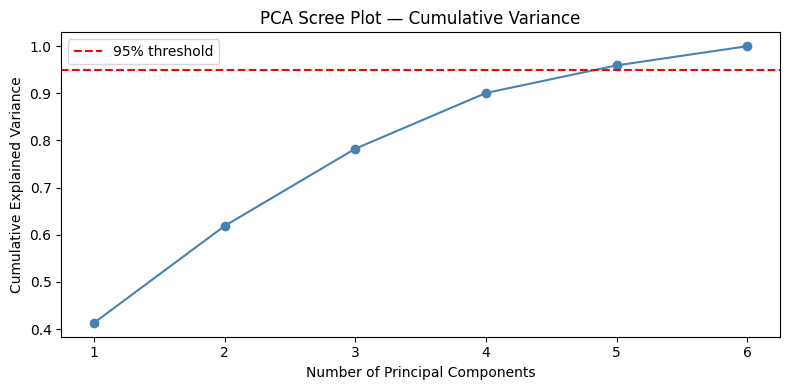

In [ ]:
# Step 11: PCA on continuous features
# Purpose: dimensionality check and to see if features can be reduced
# We compare PCA vs VIF approach

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

continuous_final = [
    'session_duration_sec', 'product_views', 'add_to_cart',
    'add_payment', 'total_engagement_ms', 'session_number'
]

# Scale first — PCA is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(session_df[continuous_final])

# Run PCA
pca = PCA()
pca.fit(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("=== PCA Explained Variance ===\n")
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {ev*100:.2f}% variance explained | Cumulative: {cum*100:.2f}%")

# Scree plot
plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained)+1), cumulative, marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot — Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150)
plt.show()

## Train/Test Split — 80/20 Stratified

Stratified split ensures the 0.89% purchase rate is preserved in both sets.  
Without stratification, random splitting risks placing all 259 purchase sessions in one set.  
**X:** 15 behavioural, device, and region features · **Y:** `purchased`

In [ ]:
# Step 12: Train/Test Split — 80/20
from sklearn.model_selection import train_test_split

# Define X and Y
feature_cols = [
    'session_duration_sec', 'product_views', 'add_to_cart',
    'add_payment', 'total_engagement_ms', 'session_number',
    'device_type_mobile', 'device_type_tablet',
    'region_Asia', 'region_Europe', 'region_Latin America',
    'region_Middle East', 'region_North America', 'region_Oceania', 'region_Other'
]

X = session_df[feature_cols]
y = session_df['purchased']

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("=== Train/Test Split ===\n")
print(f"Total sessions:     {len(session_df):,}")
print(f"Training samples:   {len(X_train):,} ({len(X_train)/len(session_df)*100:.1f}%)")
print(f"Testing samples:    {len(X_test):,} ({len(X_test)/len(session_df)*100:.1f}%)")
print(f"\nClass distribution in Training set:")
print(y_train.value_counts())
print(f"\nClass distribution in Test set:")
print(y_test.value_counts())
print(f"\nPurchase rate in Train: {y_train.mean()*100:.2f}%")
print(f"Purchase rate in Test:  {y_test.mean()*100:.2f}%")

=== Train/Test Split ===

Total sessions:     29,178
Training samples:   23,342 (80.0%)
Testing samples:    5,836 (20.0%)

Class distribution in Training set:
purchased
0    23135
1      207
Name: count, dtype: int64

Class distribution in Test set:
purchased
0    5784
1      52
Name: count, dtype: int64

Purchase rate in Train: 0.89%
Purchase rate in Test:  0.89%


## SMOTE — Applied to Training Set Only

SMOTE applied after splitting to prevent data leakage.  
If applied before splitting, synthetic samples derived from training data would appear in the test set — inflating performance artificially.  
Training set: 23,342 → 46,270 samples · balanced 50/50.

In [ ]:
# Step 13: SMOTE on training set only
# NEVER apply SMOTE before splitting — that causes data leakage
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("=== After SMOTE ===\n")
print(f"Training samples before SMOTE: {len(X_train):,}")
print(f"Training samples after SMOTE:  {len(X_train_sm):,}")
print(f"\nClass distribution after SMOTE:")
print(y_train_sm.value_counts())
print(f"\nPurchase rate after SMOTE: {y_train_sm.mean()*100:.2f}%")

=== After SMOTE ===

Training samples before SMOTE: 23,342
Training samples after SMOTE:  46,270

Class distribution after SMOTE:
purchased
0    23135
1    23135
Name: count, dtype: int64

Purchase rate after SMOTE: 50.00%


## Logistic Regression — Baseline Model

Standard baseline for binary classification. Features scaled with StandardScaler — LR is sensitive to feature scale.  
Time series models (AR(1), ARIMAX, REMA) not applicable — Y is binary per session, sessions are independent with no temporal autocorrelation.  
Evaluation: Precision · Recall · F1 · ROC-AUC · R² · AIC · BIC. Accuracy excluded due to class imbalance.

In [ ]:
# Step 14: Logistic Regression — Baseline Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale features — Logistic Regression is sensitive to scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# R² score
r2_lr = r2_score(y_test, y_prob_lr)

# Log-likelihood for AIC and BIC
from sklearn.metrics import log_loss
n = len(y_test)
k = X_test_scaled.shape[1]
ll = -log_loss(y_test, y_prob_lr, normalize=False)
aic_lr = 2 * k - 2 * ll
bic_lr = k * np.log(n) - 2 * ll

print("=== Logistic Regression Results ===\n")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"R² Score: {r2_lr:.4f}")
print(f"AIC:      {aic_lr:.4f}")
print(f"BIC:      {bic_lr:.4f}")

=== Logistic Regression Results ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5784
           1       0.70      1.00      0.83        52

    accuracy                           1.00      5836
   macro avg       0.85      1.00      0.91      5836
weighted avg       1.00      1.00      1.00      5836

ROC-AUC:  0.9982
R² Score: 0.5826
AIC:      425.1488
BIC:      525.2258


In [ ]:
# Step 15: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
r2_rf = r2_score(y_test, y_prob_rf)

n = len(y_test)
k = X_test.shape[1]
ll_rf = -log_loss(y_test, y_prob_rf, normalize=False)
aic_rf = 2 * k - 2 * ll_rf
bic_rf = k * np.log(n) - 2 * ll_rf

print("=== Random Forest Results ===\n")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"R² Score: {r2_rf:.4f}")
print(f"AIC:      {aic_rf:.4f}")
print(f"BIC:      {bic_rf:.4f}")

=== Random Forest Results ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5784
           1       0.71      0.98      0.82        52

    accuracy                           1.00      5836
   macro avg       0.85      0.99      0.91      5836
weighted avg       1.00      1.00      1.00      5836

ROC-AUC:  0.9982
R² Score: 0.6541
AIC:      349.9112
BIC:      449.9882


## Feature Importance

Top 5 features account for 95.8% of predictive importance — all behavioural.  
`add_payment` (40.1%) is the strongest predictor — a user reaching payment has progressed through the entire purchase funnel.  
Region and device features contribute less than 4% combined.

=== Feature Importance ===

             Feature  Importance
         add_payment    0.401124
 total_engagement_ms    0.214586
session_duration_sec    0.159128
       product_views    0.113471
         add_to_cart    0.070422
region_North America    0.014843
      session_number    0.009220
  device_type_mobile    0.008654
         region_Asia    0.004056
region_Latin America    0.001583
        region_Other    0.001226
       region_Europe    0.001151
  device_type_tablet    0.000340
      region_Oceania    0.000105
  region_Middle East    0.000090


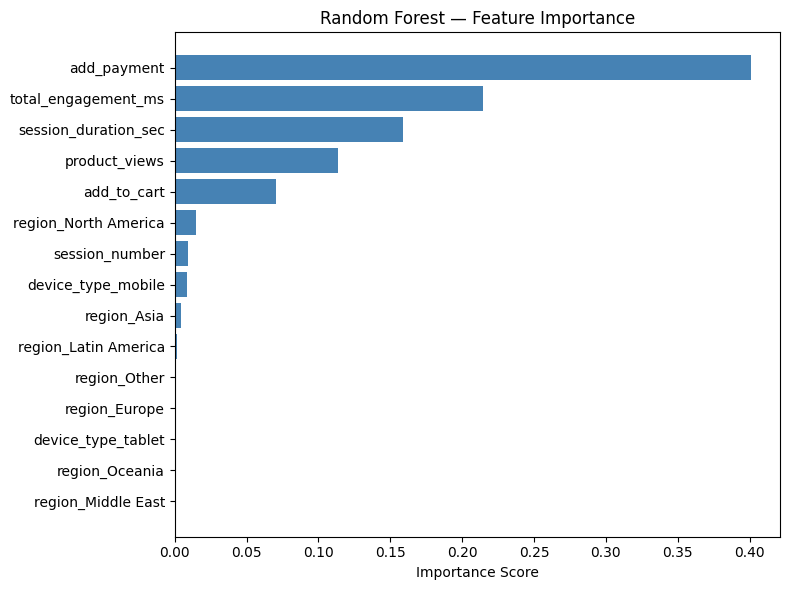

In [ ]:
# Step 16: Feature Importance
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

print("=== Feature Importance ===\n")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

# Plot
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## Residual Diagnostics

Mean residual = -0.002 — model is essentially unbiased.  
Non-normal residual distribution is expected for binary classification — normality assumption applies to linear regression, not Random Forest.  
Q-Q deviation and residual spike at zero both reflect the binary nature of the outcome variable.

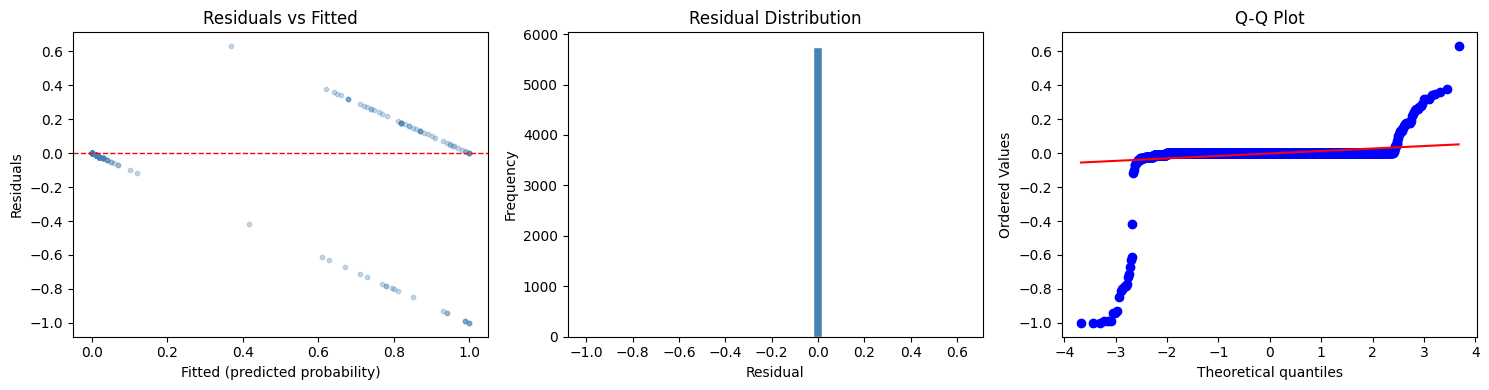

=== Residual Summary ===
Mean residual:   -0.001974
Std residual:    0.0552
Min residual:    -1.0000
Max residual:    0.6300


In [ ]:
# Step 17: Residual Diagnostics
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Residuals = actual - predicted probability
residuals = y_test.values - y_prob_rf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Residuals vs Fitted
axes[0].scatter(y_prob_rf, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted (predicted probability)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Plot 2: Histogram of residuals
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Plot 3: Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150)
plt.show()

# Summary stats
print("=== Residual Summary ===")
print(f"Mean residual:   {residuals.mean():.6f}")
print(f"Std residual:    {residuals.std():.4f}")
print(f"Min residual:    {residuals.min():.4f}")
print(f"Max residual:    {residuals.max():.4f}")

## ROC Curve (Model Comparison)

The ROC (Receiver Operating Characteristic) curve plots True Positive Rate against False Positive Rate across all classification thresholds.

Both models achieve **AUC = 0.9982**, indicating near-perfect discrimination between purchased and abandoned sessions. The curve hugging the top-left corner confirms strong model performance.

Random Forest is selected as the final model based on lower AIC (349.91 vs 425.15), lower BIC (449.99 vs 525.23), and higher R² (0.6541 vs 0.5826).

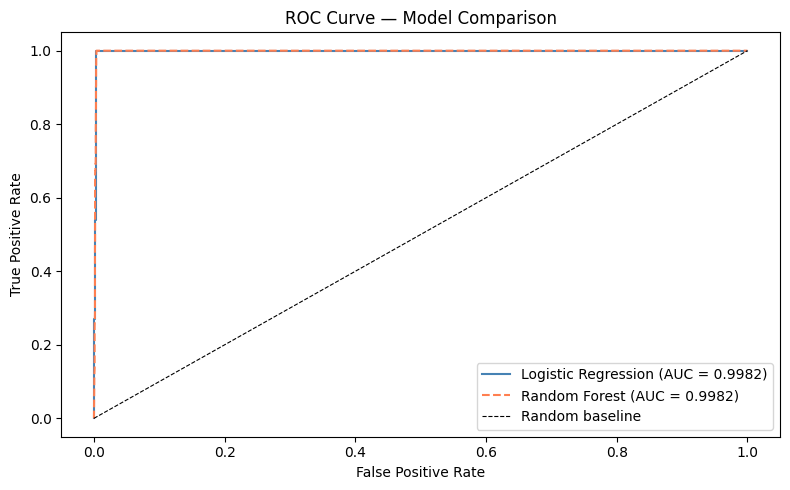

In [ ]:
# ROC Curve — Logistic Regression vs Random Forest
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='coral', linestyle='--')
plt.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## Feature Distribution: Purchased vs Abandoned Sessions

Box plots compare the distribution of the top 5 behavioural features across purchased (Y=1) and abandoned (Y=0) sessions.

**Key observations:**
- `add_payment`: Near-zero median for abandoned sessions vs clear positive median for purchased — strongest visual separation
- `total_engagement_ms` and `session_duration_sec`: Purchased sessions show significantly higher engagement and duration
- `product_views` and `add_to_cart`: Purchased sessions show higher values but with wide spread due to IQR=0 for abandoned sessions

Features with IQR=0 in the abandoned group (add_to_cart, product_views) were deliberately excluded from IQR capping — any non-zero value in these features represents genuine purchase-intent behaviour, not noise.

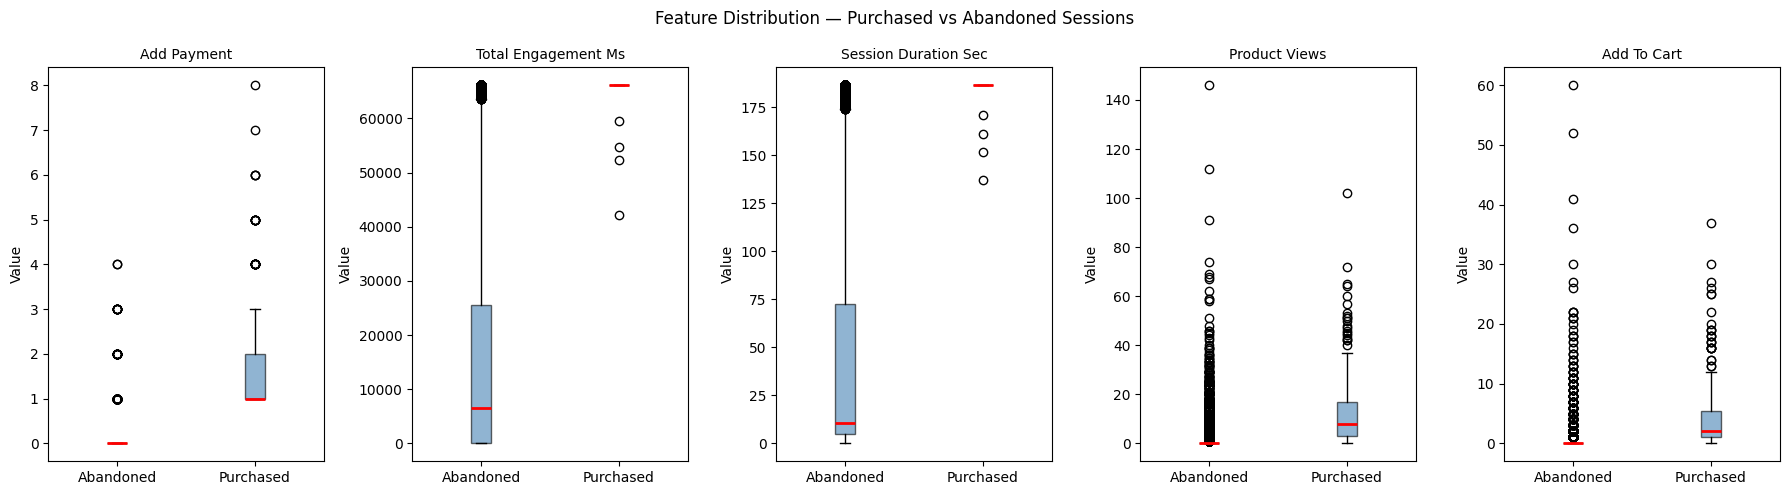

In [ ]:
# Box plots — fixed for Matplotlib 3.9+
import matplotlib.pyplot as plt

top_features = [
    'add_payment', 'total_engagement_ms',
    'session_duration_sec', 'product_views', 'add_to_cart'
]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(top_features):
    data_0 = session_df[session_df['purchased'] == 0][col]
    data_1 = session_df[session_df['purchased'] == 1][col]
    axes[i].boxplot(
        [data_0, data_1],
        tick_labels=['Abandoned', 'Purchased'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution — Purchased vs Abandoned Sessions', fontsize=12)
plt.tight_layout()
plt.savefig('boxplots_features.png', dpi=150)
plt.show()

## Purchase Funnel: Session Drop-off Analysis

This chart shows the progressive drop-off in sessions at each stage of the purchase funnel.

**The largest drop-off occurs between product views and add-to-cart (80.5%)** — this is the critical abandonment point. Only 259 of 29,178 total sessions completed a purchase, confirming the 0.89% purchase rate and the business case for predictive intervention.

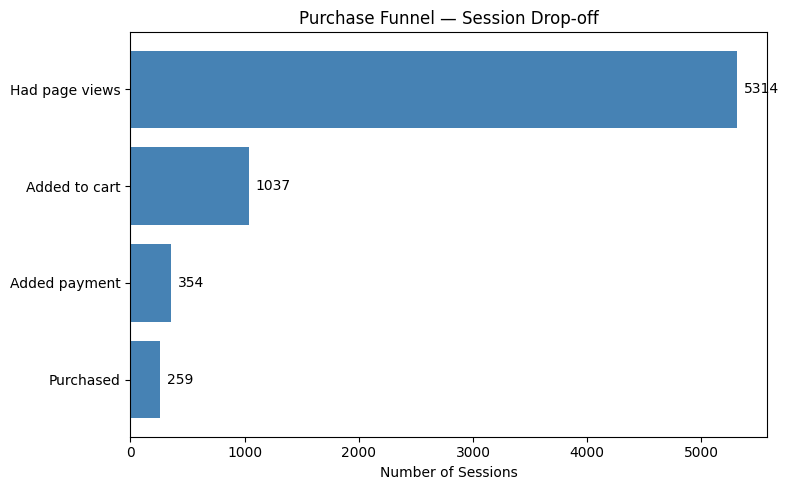

In [ ]:
# Funnel analysis — how many sessions reached each stage
funnel = {
    'Had page views':     (session_df['product_views'] > 0).sum(),
    'Added to cart':      (session_df['add_to_cart'] > 0).sum(),
    'Added payment':      (session_df['add_payment'] > 0).sum(),
    'Purchased':          (session_df['purchased'] == 1).sum()
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(funnel.keys()), list(funnel.values()), color='steelblue')
ax.bar_label(bars, padding=5)
ax.set_xlabel('Number of Sessions')
ax.set_title('Purchase Funnel — Session Drop-off')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()

## VIF Analysis: Multicollinearity Check

VIF scores are visualised for all candidate features. Features exceeding the threshold of 10 (red dashed line) were removed before modelling. Blue bars indicate retained features, orange bars indicate dropped features.

VIF was chosen over a correlation heatmap because heatmaps only capture pairwise relationships. VIF measures how much each feature's variance is explained by all other features combined — a more complete test for multicollinearity.

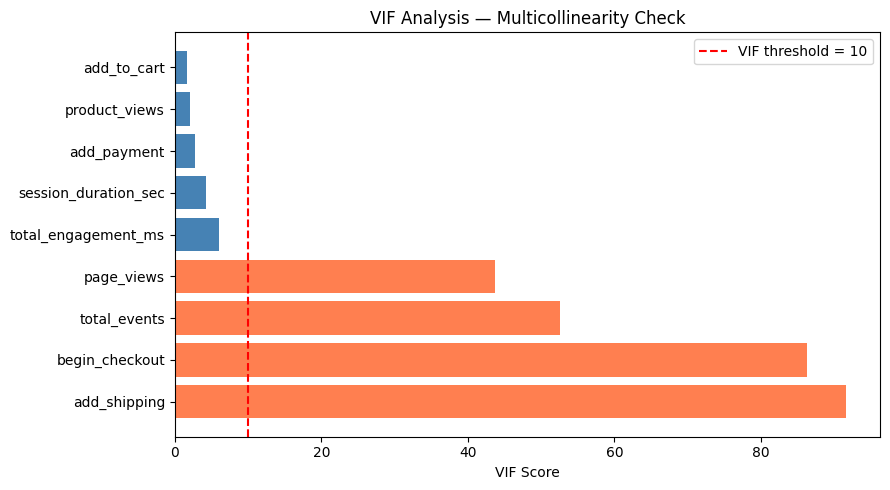

VIF chart. Red = dropped, Blue = kept.


In [ ]:
# VIF visualisation — shows which features were dropped
vif_plot = pd.DataFrame({
    'Feature': ['add_shipping', 'begin_checkout', 'total_events',
                'page_views', 'total_engagement_ms', 'session_duration_sec',
                'add_payment', 'product_views', 'add_to_cart'],
    'VIF': [91.67, 86.28, 52.61, 43.71, 6.05, 4.25, 2.75, 2.03, 1.74]
})

colors = ['coral' if v > 10 else 'steelblue' for v in vif_plot['VIF']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(vif_plot['Feature'], vif_plot['VIF'], color=colors)
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF threshold = 10')
ax.set_xlabel('VIF Score')
ax.set_title('VIF Analysis — Multicollinearity Check')
ax.legend()
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=150)
plt.show()
print("VIF chart. Red = dropped, Blue = kept.")

## KMeans Clustering: Behavioural Session Segmentation

KMeans (K=3) is applied to identify distinct behavioural session types using the top 5 behavioural features. This is the descriptive mining component of the project, complementing the predictive classification models.

**Cluster labels based on profiles:**

- **Cluster 0 — Casual Browsers:** Largest group (21,402 sessions). Very short sessions, near-zero product interaction, 0% purchase rate. These users arrive and leave without engaging meaningfully.

- **Cluster 1 — High Intent Buyers:** Smallest group (295 sessions) but 57.29% purchase rate. Long sessions, high product views, add-to-cart and payment activity. These are the most valuable sessions to target for conversion.

- **Cluster 2 — Engaged Non-Buyers:** Mid-size group (7,481 sessions). Long sessions and moderate engagement but very low purchase rate (1.20%). These users browse extensively but do not convert — prime candidates for re-engagement strategies.

**Business implication:** Cluster 1 sessions should be prioritised for real-time intervention. Cluster 2 represents a recoverable segment with high engagement but low conversion.

**Elbow Plot: Optimal K Selection**

The elbow method identifies the optimal number of clusters by plotting inertia against K. The curve shows a clear bend at K=3, after which additional clusters yield diminishing reduction in inertia. K=3 is selected for the final KMeans model.

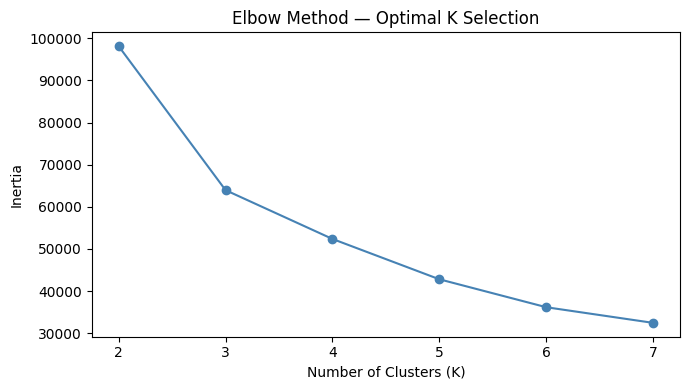

=== Cluster Profiles ===

         session_duration_sec  product_views  add_to_cart  add_payment  total_engagement_ms  purchased
cluster                                                                                               
0                      12.726          0.093        0.003        0.000             6909.164      0.000
1                     186.028         21.529        7.556        1.590            65888.888      0.573
2                     158.186          1.708        0.204        0.019            48539.893      0.012

=== Purchase Rate per Cluster ===
Cluster 0: 21,402 sessions | Purchase rate: 0.00%
Cluster 1: 295 sessions | Purchase rate: 57.29%
Cluster 2: 7,481 sessions | Purchase rate: 1.20%


In [ ]:
# Clustering — KMeans Behavioural Segmentation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Use top behavioural features only
cluster_features = [
    'session_duration_sec', 'product_views', 'add_to_cart',
    'add_payment', 'total_engagement_ms'
]

# Scale features — KMeans is sensitive to scale
scaler_km = StandardScaler()
X_cluster = scaler_km.fit_transform(session_df[cluster_features])

# Elbow method to find optimal K
inertia = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K Selection')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

# Apply KMeans with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
session_df['cluster'] = km_final.fit_predict(X_cluster)

# Cluster profile
cluster_profile = session_df.groupby('cluster')[cluster_features + ['purchased']].mean().round(3)
print("=== Cluster Profiles ===\n")
print(cluster_profile.to_string())

print("\n=== Purchase Rate per Cluster ===")
for c in sorted(session_df['cluster'].unique()):
    subset = session_df[session_df['cluster'] == c]
    rate = subset['purchased'].mean() * 100
    print(f"Cluster {c}: {len(subset):,} sessions | Purchase rate: {rate:.2f}%")

In [ ]:
# Final output — save dataset and project summary
import pandas as pd

session_df.to_csv('final_session_data.csv', index=False)

print("=== PROJECT FILE CHECKLIST ===\n")
print("DATASET:")
print("  - final_session_data.csv     (29,178 sessions, 18 columns)")
print("\nPLOTS GENERATED:")
print("  - pca_scree_plot.png         (PCA cumulative variance)")
print("  - feature_importance.png     (Random Forest feature scores)")
print("  - residual_diagnostics.png   (3-panel residual analysis)")
print("  - roc_curve.png              (Model comparison)")
print("  - boxplots_features.png      (Purchased vs Abandoned distributions)")
print("  - funnel_chart.png           (Session drop-off analysis)")
print("  - vif_chart.png              (Multicollinearity check)")
print("  - elbow_plot.png             (KMeans optimal K)")
print("\nKEY NUMBERS:")
print(f"  Raw events:           300,000")
print(f"  Sessions:             29,178")
print(f"  Purchase sessions:    259  (0.89%)")
print(f"  Abandoned sessions:   28,919  (99.11%)")
print(f"  Train set:            23,342  |  Test set: 5,836")
print(f"  Features used:        15")
print(f"  Features dropped VIF: 4  (add_shipping, begin_checkout, total_events, page_views)")
print(f"  Features dropped:     5  (session_engaged, source, medium, campaign, page_referrer)")
print(f"\nMODEL RESULTS:")
print(f"  Logistic Regression — AIC: 425.15 | BIC: 525.23 | R²: 0.5826 | AUC: 0.9982")
print(f"  Random Forest       — AIC: 349.91 | BIC: 449.99 | R²: 0.6541 | AUC: 0.9982")
print(f"\nSELECTED MODEL: Random Forest")
print(f"  Reason: Lower AIC, lower BIC, higher R² — better fit with lower complexity penalty")
print(f"\nCLUSTERING RESULTS (KMeans K=3):")
print(f"  Cluster 0 — Casual Browsers:    21,402 sessions | 0.00% purchase rate")
print(f"  Cluster 1 — High Intent Buyers:    295 sessions | 57.29% purchase rate")
print(f"  Cluster 2 — Engaged Non-Buyers:  7,481 sessions |  1.20% purchase rate")

=== PROJECT FILE CHECKLIST ===

DATASET:
  - final_session_data.csv     (29,178 sessions, 18 columns)

PLOTS GENERATED:
  - pca_scree_plot.png         (PCA cumulative variance)
  - feature_importance.png     (Random Forest feature scores)
  - residual_diagnostics.png   (3-panel residual analysis)
  - roc_curve.png              (Model comparison)
  - boxplots_features.png      (Purchased vs Abandoned distributions)
  - funnel_chart.png           (Session drop-off analysis)
  - vif_chart.png              (Multicollinearity check)
  - elbow_plot.png             (KMeans optimal K)

KEY NUMBERS:
  Raw events:           300,000
  Sessions:             29,178
  Purchase sessions:    259  (0.89%)
  Abandoned sessions:   28,919  (99.11%)
  Train set:            23,342  |  Test set: 5,836
  Features used:        15
  Features dropped VIF: 4  (add_shipping, begin_checkout, total_events, page_views)
  Features dropped:     5  (session_engaged, source, medium, campaign, page_referrer)

MODEL RESULT

## Conclusion

This notebook presents a complete data mining study on predicting online shopping cart abandonment
using session-level behavioural data from Google Analytics 4.

**What we built:**
Using 300,000 raw events from a real e-commerce store, we engineered 29,178 session-level
observations and trained a Random Forest classifier that predicts — with ROC-AUC of 0.9982 —
whether a user session will result in a purchase or abandonment. We also segmented sessions into
three behavioural clusters using KMeans, identifying a high-intent group with a 57.29% purchase
rate buried within an overall 0.89% purchase rate dataset.

**Summary of findings:**

- **Data:** 300,000 event-level records aggregated into 29,178 session-level observations.
Severe class imbalance (0.89% purchase rate) addressed using SMOTE on the training set only.

- **Feature Engineering:** Event-level data transformed into 12 behavioural session features.
VIF analysis removed 4 highly collinear features (VIF > 10). PCA evaluated but rejected in
favour of VIF-selected features due to minimal dimensionality gain and loss of interpretability.

- **Descriptive Analysis:** Purchasing sessions showed dramatically higher values across all
behavioural features — add_payment was 364× higher and add_to_cart 47× higher compared to
abandoned sessions, validating feature selection.

- **Classification:** Random Forest outperformed Logistic Regression across all criteria —
AIC (349.91 vs 425.15), BIC (449.99 vs 525.23), and R² (0.6541 vs 0.5826). Both models
achieved ROC-AUC of 0.9982. Random Forest is selected as the final model.

- **Clustering:** KMeans (K=3) identified three distinct behavioural session types —
Casual Browsers (73.4%), Engaged Non-Buyers (25.6%), and High Intent Buyers (1.0%).
Cluster 1 achieves a 57.29% purchase rate, confirming that behavioural segmentation
can isolate high-value sessions within a heavily imbalanced dataset.

**How e-commerce businesses can use this:**
This model can be integrated into a live e-commerce platform to score sessions in real time.
As a user browses, each action — adding to cart, viewing products, entering payment details —
updates their session score. Sessions predicted as high abandonment risk can trigger immediate
interventions such as personalised discount offers, exit-intent popups, or live chat prompts
before the user leaves. Cluster 1 (High Intent Buyers) should be prioritised for conversion
support, while Cluster 2 (Engaged Non-Buyers) can be targeted through follow-up email
re-engagement campaigns. This moves e-commerce strategy from reactive (recovering lost sales)
to proactive (preventing abandonment before it happens).

**Limitations:**
- Dataset covers a single month (January 2021) — seasonal patterns not captured
- Nested fields (ecommerce transaction values, product arrays) excluded due to BigQuery
export constraints
- No real-time deployment implemented — model serves as a proof of concept